Dimensiones de la imagen: (275, 500, 3)


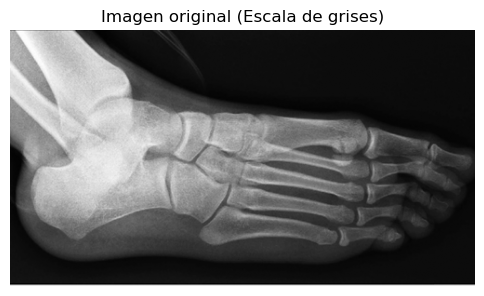

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as imageio
import scipy.ndimage as ndi

# === CARGA DE IMAGEN ===
im = imageio.imread('RXPie.jpg')

# Mostrar forma y tipo
print("Dimensiones de la imagen:", im.shape)

# Si es RGB, la convertimos a escala de grises (promedio de canales)
if len(im.shape) == 3:
    im_gray = np.mean(im, axis=2)
else:
    im_gray = im

# Mostrar la imagen
plt.figure(figsize=(6,6))
plt.imshow(im_gray, cmap='gray')
plt.title('Imagen original (Escala de grises)')
plt.axis('off')
plt.show()


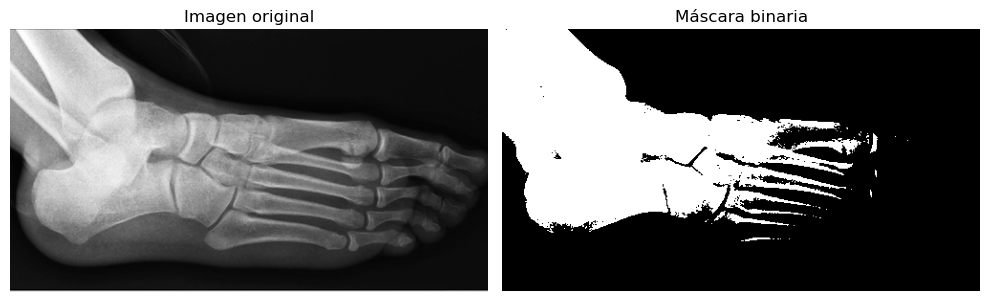

In [8]:
# === CREACIÓN DE MÁSCARA BINARIA ===

# Definimos un umbral (ajústalo según tu imagen)
umbral = 120

# Crear la máscara binaria: 1 si el valor del píxel es mayor al umbral
mask = im_gray > umbral

# Mostrar imagen original y máscara
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im_gray, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Máscara binaria')
axes[1].axis('off')

plt.tight_layout()
plt.show()



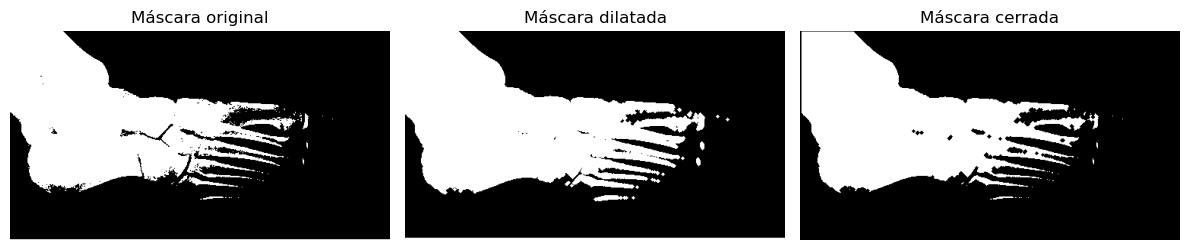

In [9]:
# === OPERACIONES MORFOLÓGICAS ===

# Dilatación (agranda las regiones blancas)
mask_dilated = ndi.binary_dilation(mask, iterations=2)

# Cierre (rellena huecos pequeños)
mask_closed = ndi.binary_closing(mask, iterations=2)

# Mostrar comparación
fig, axes = plt.subplots(1, 3, figsize=(12,5))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Máscara original')
axes[0].axis('off')

axes[1].imshow(mask_dilated, cmap='gray')
axes[1].set_title('Máscara dilatada')
axes[1].axis('off')

axes[2].imshow(mask_closed, cmap='gray')
axes[2].set_title('Máscara cerrada')
axes[2].axis('off')

plt.tight_layout()
plt.show()



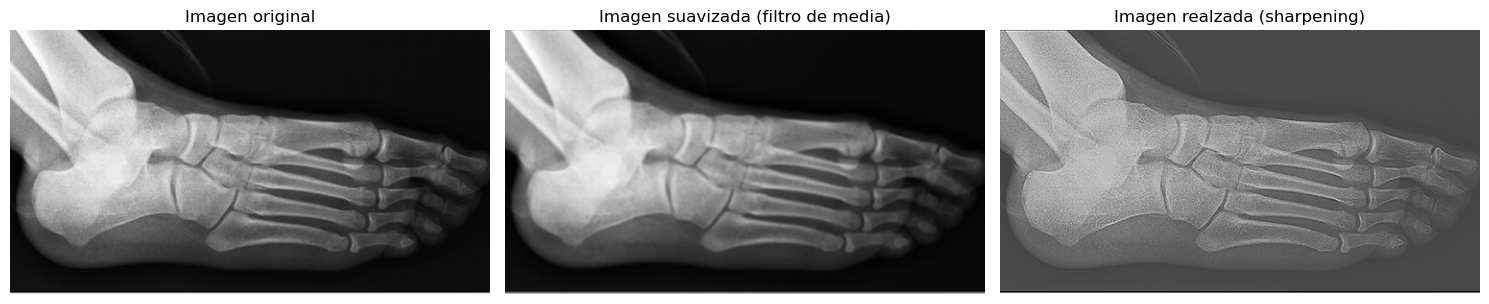

In [10]:
# === FILTRADO CON CONVOLUCIÓN ===

# Kernel de suavizado (media 3x3)
kernel_media = np.ones((3,3)) / 9.0

# Aplicar convolución (suavizado)
imagen_suavizada = ndi.convolve(im_gray, kernel_media)

# Kernel de realce (sharpening)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

# Aplicar convolución (realce)
imagen_realzada = ndi.convolve(im_gray, kernel_sharp)

# Mostrar comparaciones
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(im_gray, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(imagen_suavizada, cmap='gray')
axes[1].set_title('Imagen suavizada (filtro de media)')
axes[1].axis('off')

axes[2].imshow(imagen_realzada, cmap='gray')
axes[2].set_title('Imagen realzada (sharpening)')
axes[2].axis('off')

plt.tight_layout()
plt.show()



1. La dilatación aumentó el tamaño de las regiones blancas, permitiendo resaltar estructuras.
2. El cierre rellenó huecos pequeños, haciendo las áreas más uniformes.
3. El filtro de media suaviza la imagen, reduciendo el ruido pero perdiendo detalle.
4. El filtro de realce (sharpening) aumenta el contraste de los bordes, mejorando la visibilidad.
5. Estas técnicas permiten resaltar estructuras anatómicas, limpiar ruido y mejorar el diagnóstico visual.

